# INF4039 Giliojo mokymo sistemų taikymai / Deep Learning Systems
**LAB5**

## HOMEWORK TASK (OPTIONAL)

Create a Convolutional Neural Network for image classification task from one of the following datasets:
1. Classify images of clothes using the Fashion MNIST dataset: https://www.kaggle.com/datasets/zalando-research/fashionmnist
2. Teach the network to distinguish a cat from a dog: https://www.kaggle.com/competitions/dogs-vs-cats/data
3. Classify music genres using the dataset of songs spectrograms: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification
4. Any other dataset, which is suitable for prediction task.

Your Notebook/script should have the following parts:
1. Data exploration (visualizing data, describing what values will be used for training, what is the target of the classification, etc.);
2. Data preparation (fill empty values, remove outliers, check the correlations);
3. Split the data into train and test sets;
4. Neural network - try at least three different structures and see which one is the best for learning;
5. Model evaluation (accuracy, loss, ROC curve, etc.) - at leas two evaluation methods.

# Image classification using Convolutional Neural Networks (CNN)

In this lab we will learn how to classify images using Keras deep learing library several different image datasets.

First we’re going to tackle a classic introductory Computer Vision problem: MNIST handwritten digit classification. The task is: given an image, classify it as a digit.

<img src="https://raw.githubusercontent.com/vytkuc/inf4039_2024_autumn/refs/heads/main/lab05_CNN/img/mnist.webp"
     width=750 height=500
     style="display: block; margin: 0 auto"/>

Each image in the MNIST dataset is a 28x28 matrix, which contains a centered, grayscale digit. Our CNN will take an image and output one of 10 possible classes (one for each digit).

In [9]:
# Install the dataset library
!pip install mnist

In [10]:
import numpy as np
import mnist
#from tensorflow import keras
import matplotlib.pyplot as plt

## Load the dataset

In this case there is no need to do the train / test split since we can load already split data from the MNIST library.

In [11]:
# The first time you run this might be a bit slow, since the
# mnist package has to download and cache the data.
from tensorflow.keras.datasets import mnist

# Download and load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print("Training images:", train_images.shape)
print("Training labels:", train_labels.shape)
print("Test images:", test_images.shape)
print("Test labels:", test_labels.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


Label: 4


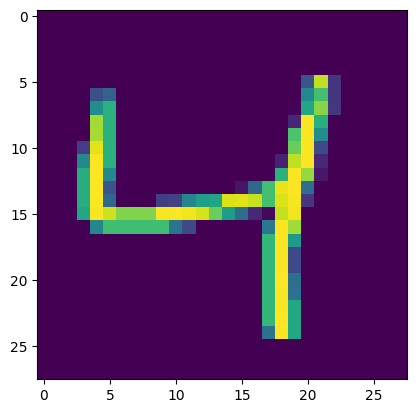

In [12]:
index = 2

plt.imshow(train_images[index]);
print(f"Label: {train_labels[index]}")
#print(train_images[index])

## Data preparation

We will normalize the image pixel values from [0, 255] to [-0.5, 0.5] to make our network easier to train (using smaller, centered values usually leads to better results). We’ll also reshape each image from (28, 28) to (28, 28, 1) because Keras requires the third dimension.

In [13]:
# Normalize the images
train_images = (train_images / 255) - 0.5
test_images = (test_images / 255) - 0.5

# Reshape the images
train_images = np.expand_dims(train_images, axis=3)
test_images = np.expand_dims(test_images, axis=3)

print(train_images.shape)
print(test_images.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


## Building the model

<img src="https://raw.githubusercontent.com/vytkuc/inf4039_2024_autumn/refs/heads/main/lab05_CNN/img/cnn.svg"
     width=650 height=400
     style="display: block; margin: 0 auto"/>

     

In [14]:
train_images[0].shape

(28, 28, 1)

## Essential CNN layers and their parameters

A CNN first extracts local patterns from an image using convolutional layers, reduces the spatial dimensions using pooling, and then prepares the extracted features for classification. With the default `channels_last` format, one image has shape `(height, width, channels)`. MNIST images therefore have shape `(28, 28, 1)`. A batch adds a leading dimension: `(batch_size, height, width, channels)`.

**Layer settings are hyperparameters** chosen before training, such as the number of filters or pooling window size. **Trainable parameters** are weights and biases learned during training. `Conv2D` has trainable parameters; `MaxPooling2D` and `Flatten` do not.


### 1. Convolution: `Conv2D`

A convolutional layer slides learned filters (kernels) across the image. Each filter combines values from a small spatial neighbourhood across all input channels to produce one output feature map. The same filter weights are reused at every position. During training, filters can learn useful patterns such as edges and textures.

| Parameter | Meaning and effect | Value in this notebook |
| --- | --- | --- |
| `filters` | Number of learned filters and output feature maps. More filters can capture more patterns, but increase computation and the number of trainable parameters. | `num_filters = 8` |
| `kernel_size` | Height and width of each filter. Larger kernels cover a wider neighbourhood and require more weights. An integer applies to both dimensions. | `filter_size = 3`, meaning `(3, 3)` |
| `strides` | How far the filter moves at each step. Larger strides usually reduce the output height and width. | Default `(1, 1)` |
| `padding` | `"valid"` adds no padding and usually reduces spatial dimensions. `"same"` adds padding; with stride 1, it preserves height and width. | Default `"valid"` |
| `activation` | Nonlinear function applied to the convolution output. `"relu"` replaces negative values with zero. If omitted, the layer uses a linear activation. | Omitted: **both convolutional layers are linear** |
| `use_bias` | Adds one learned bias per output filter. | Default `True` |
| `input_shape` | Shape of one input sample, excluding the batch dimension. It describes the input rather than a learned parameter. | `(28, 28, 1)` in the first layer |
| `data_format` | Channel position: `"channels_last"` uses `(height, width, channels)`; `"channels_first"` uses `(channels, height, width)`. | The lab assumes `"channels_last"` |

For stride 1 and `padding="valid"`, a 3 × 3 kernel changes the height and width from `H × W` to `(H − 2) × (W − 2)`.

The number of trainable parameters, with bias enabled, is:

`(kernel_height × kernel_width × input_channels + 1) × filters`

- First convolution: `(3 × 3 × 1 + 1) × 8 = 80` parameters; output shape `(26, 26, 8)`.
- Second convolution: `(3 × 3 × 8 + 1) × 8 = 584` parameters; output shape `(24, 24, 8)`.

**Experiment:** adding `activation="relu"` to each `Conv2D` introduces nonlinearity after each convolution. Compare the resulting validation performance with the current model.


### 2. Max pooling: `MaxPooling2D`

Max pooling keeps the largest value in each spatial window, separately for every feature map. It reduces the height and width while preserving the number of channels. This lowers the computational cost of later layers and can make features less sensitive to small spatial shifts, although some spatial detail is lost.

For example, a 2 × 2 window containing `[[1, 3], [2, 0]]` produces the single value `3`. Pooling uses a fixed operation: **it learns no weights or biases**.

| Parameter | Meaning and effect | Value in this notebook |
| --- | --- | --- |
| `pool_size` | Height and width of the pooling window. Larger windows usually discard more spatial detail. | `pool_size = 2`, meaning `(2, 2)` |
| `strides` | Distance between successive windows. If `None`, it equals `pool_size`. A smaller stride can create overlapping windows. | Default `None`, so the effective stride is `(2, 2)` |
| `padding` | `"valid"` uses only complete windows. `"same"` pads as needed and gives output size `ceil(input_size / stride)` along each spatial dimension. | Default `"valid"` |
| `data_format` | Specifies where the channel dimension is located. Use a consistent format across the model. | The lab assumes `"channels_last"` |

Here, `(24, 24, 8)` becomes `(12, 12, 8)`: each 2 × 2 window contributes one value, and all 8 channels are retained. The number of trainable parameters is **0**.


### 3. Flatten: `Flatten`

`Flatten` reshapes each sample's multidimensional feature maps into one vector so that a `Dense` layer can use them. It preserves the values and their total count; it does not average, select, or learn features. The batch dimension is preserved.

| Parameter or property | Meaning | Value in this notebook |
| --- | --- | --- |
| `data_format` | Describes the location of the channel dimension in the input. | The lab assumes `"channels_last"` |
| Output length | Product of all non-batch input dimensions. It is determined by the input shape, not set as a separate argument. | `12 × 12 × 8 = 1152` |
| Trainable parameters | `Flatten` only reshapes the data. | **0** |

`Flatten()` has no `filters`, `kernel_size`, `pool_size`, or `units` parameter. The number of neurons is specified in the following `Dense` layer.

### Shapes and parameter counts in this model

The batch dimension is omitted below. In `model.summary()`, it is usually shown as `None` because the model can process different batch sizes.

| Layer | Output shape per sample | Trainable parameters |
| --- | --- | --- |
| Input | `(28, 28, 1)` | 0 |
| First `Conv2D(8, 3)` | `(26, 26, 8)` | 80 |
| Second `Conv2D(8, 3)` | `(24, 24, 8)` | 584 |
| `MaxPooling2D(pool_size=2)` | `(12, 12, 8)` | 0 |
| `Dropout(0.5)` | `(12, 12, 8)` | 0 |
| `Flatten()` | `(1152,)` | 0 |
| `Dense(64, activation="relu")` | `(64,)` | `(1152 + 1) × 64 = 73,792` |
| `Dense(10, activation="softmax")` | `(10,)` | `(64 + 1) × 10 = 650` |

`Dropout(0.5)` randomly sets approximately half of its input values to zero during training and scales the retained values. It is inactive during normal validation and prediction and does not change the tensor shape.

**Total: 75,106 trainable parameters.** Most belong to the first `Dense` layer. Although `Flatten` itself has no learned parameters, a larger flattened vector increases the number of weights needed by the next `Dense` layer.

**Try changing one setting at a time:** increase `num_filters` from 8 to 16, change `filter_size` from 3 to 5, or change `pool_size` from 2 to 3. Before training, predict the new output shapes and parameter counts, then check them using `model.summary()`.


In [15]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras import layers

np.random.seed(1337)


num_filters = 8
filter_size = 3
pool_size = 2

model = keras.Sequential(
    [
        layers.Conv2D(num_filters, filter_size, input_shape=train_images[0].shape),
        layers.Conv2D(num_filters, filter_size),
        layers.MaxPooling2D(pool_size=pool_size),
        layers.Dropout(0.5),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation = "softmax"),
    ]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,106 (293.38 KB)

 Trainable params: 75,106 (293.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.utils import to_categorical
import datetime

model.compile(
  'adam',
  loss='categorical_crossentropy',
  metrics=['accuracy'],
)

# Tensorboard logs dir
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

model.fit(
  train_images,
  to_categorical(train_labels),
  epochs=3,
  validation_data=(test_images, to_categorical(test_labels)),
  callbacks=[tensorboard_callback]
);

Epoch 1/3
 535/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - accuracy: 0.7037 - loss: 0.9080

In [ ]:
%load_ext tensorboard

## Saving the model

In [ ]:
model.get_weights()

In [ ]:
#model.save_weights('cnn.h5')